# Rossmann Sales Exploratory Data Analysis

Digging into what drives sales across the 1,115 German Rossmann stores, mostly through Python visualizations.

## A few things I want to figure out:
1. Which stores actually sell the most?
2. Do promotions moves sales, or just feel like they should?
3. Any seasonal patterns worth nothing?
4. Does store type change how much a store earns?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('../data/clean/merged_cleaned.csv', low_memory =False)

In [5]:
print(df.shape)
df.head()

(844338, 23)


,store,dayofweek,date,sales,customers,open,promo,stateholiday,schoolholiday,year,...,storetype,assortment,competitiondistance,competitionopensincemonth,competitionopensinceyear,promo2,promo2sinceweek,promo2sinceyear,promointerval,competitiondistance_imputed
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,...,c,a,1270.0,9,2008,0,0,0,0,0
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,...,a,a,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct",0
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,...,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct",0
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,...,c,c,620.0,9,2009,0,0,0,0,0
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,...,a,a,29910.0,4,2015,0,0,0,0,0


## Top 10 Stores by Average Daily Sales
Which stores bring in the most revenue?  
Store 817 leads the pack with €21,757 IN AVERAGE DAILY SALES, ROUGHLY 3X THE OVERALL AVERAGE OF €6,955.

In [6]:
top_stores = df.groupby('store')['sales'].mean().sort_values(ascending = False).head(10)
top_stores

store
817     21757.483418
262     20718.515924
1114    20666.562500
251     19123.068036
842     18574.795820
513     18179.089286
562     17969.556263
788     17961.914541
383     17294.716667
756     16574.816431
Name: sales, dtype: float64

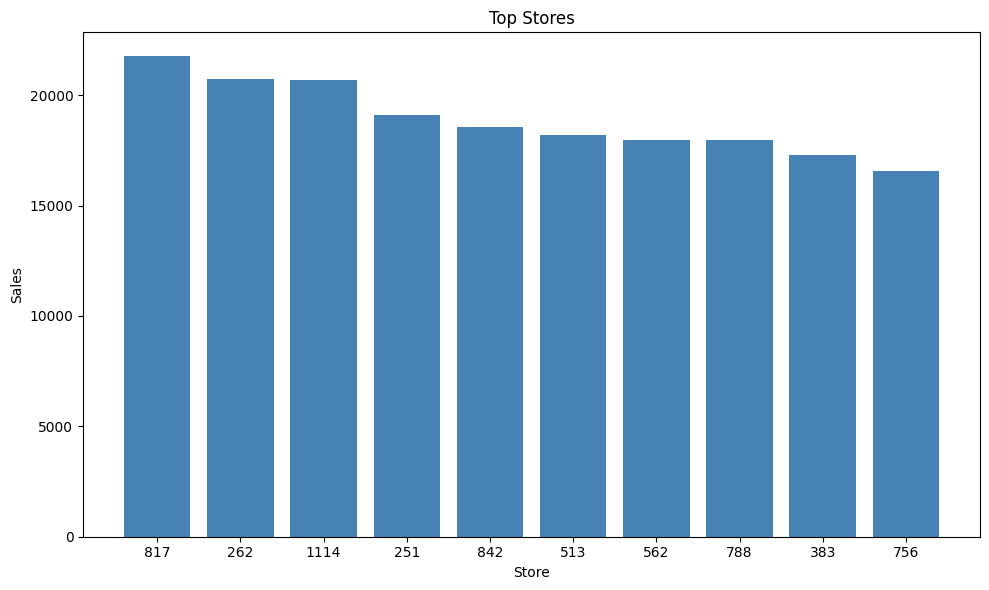

In [7]:
plt.figure(figsize = (10,6))
plt.bar(top_stores.index.astype(str), top_stores.values, color = 'steelblue')
plt.title('Top Stores')
plt.xlabel('Store')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('../charts/top_stores.png')
plt.show()

In [8]:
top_3 = [817, 262, 1114]
df[df['store'].isin(top_3)][['store', 'storetype', 'assortment', 'competitiondistance']].drop_duplicates()

,store,storetype,assortment,competitiondistance
261,262,b,a,1180.0
815,817,a,a,140.0
1111,1114,a,c,870.0


## Promotion Impact on Sales
Do promotions actually increase sales?  
Yes, and by a decent margin: average daily sales jump 38% during promotions, from €5,929 up to €8,228.

In [11]:
promo_sales = df.groupby('promo')['sales'].mean()
promo_sales

promo
0    5929.826183
1    8228.739731
Name: sales, dtype: float64

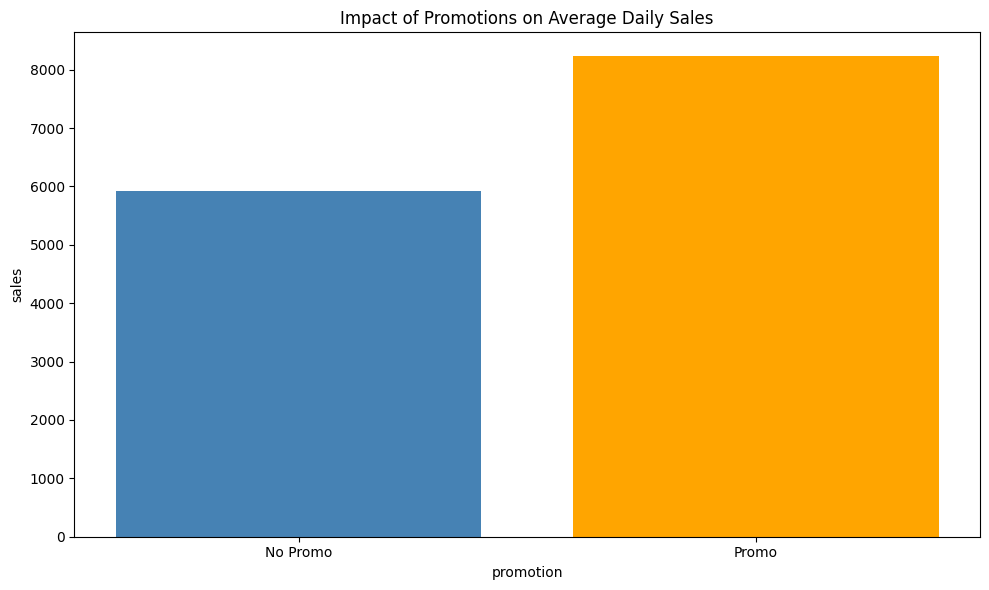

In [12]:
plt.figure(figsize = (10,6))
plt.bar(['No Promo','Promo'], promo_sales.values , color= ['steelblue','orange'])
plt.title('Impact of Promotions on Average Daily Sales')
plt.xlabel('promotion')
plt.ylabel('sales')
plt.tight_layout()
plt.savefig('../charts/promo_sales.png')
plt.show()

##  Monthly Sales Trend
 What seasonal patterns show up across the year?  
 December stands out: sales spike 49% above the yearly average, which lines up with strong Christmas seasonality.

In [13]:
monthly_sales = df.groupby('month')['sales'].mean()
monthly_sales

month
1     6564.298651
2     6589.494012
3     6976.817749
4     7046.659509
5     7106.808038
6     7001.402127
7     6953.575827
8     6649.229053
9     6547.469104
10    6602.967255
11    7188.554250
12    8608.956661
Name: sales, dtype: float64

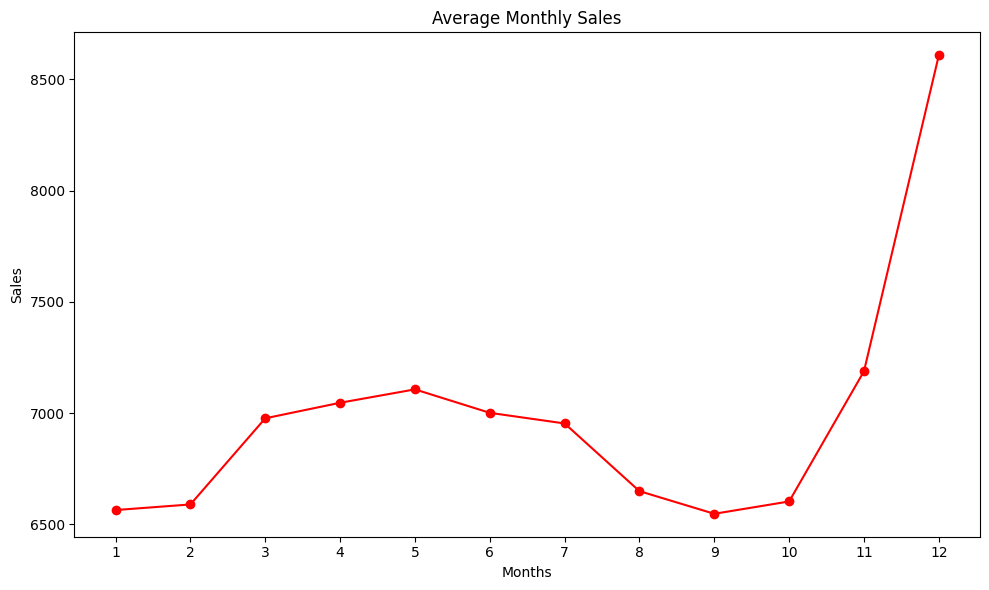

In [14]:
plt.figure(figsize = (10,6))
plt.plot(monthly_sales.index, monthly_sales.values,marker='o',color = 'red')
plt.title('Average Monthly Sales')
plt.xlabel('Months')
plt.ylabel('Sales')
plt.xticks(range(1,13))
plt.tight_layout()
plt.savefig('../charts/monthly_sales.png', dpi=150)
plt.show()

In [15]:
df.columns

Index(['store', 'dayofweek', 'date', 'sales', 'customers', 'open', 'promo',
       'stateholiday', 'schoolholiday', 'year', 'month', 'weekofyear', 'day',
       'storetype', 'assortment', 'competitiondistance',
       'competitionopensincemonth', 'competitionopensinceyear', 'promo2',
       'promo2sinceweek', 'promo2sinceyear', 'promointerval',
       'competitiondistance_imputed'],
      dtype='object')

## Sales by Store Type
Which store format brings in the most revenue?  
Type b stands out here, averaging 48% higher daily sales than types a,c, and d.

In [16]:
storetype_sales = df.groupby('storetype')['sales'].mean()
storetype_sales

storetype
a     6925.697986
b    10233.380141
c     6933.126425
d     6822.300064
Name: sales, dtype: float64

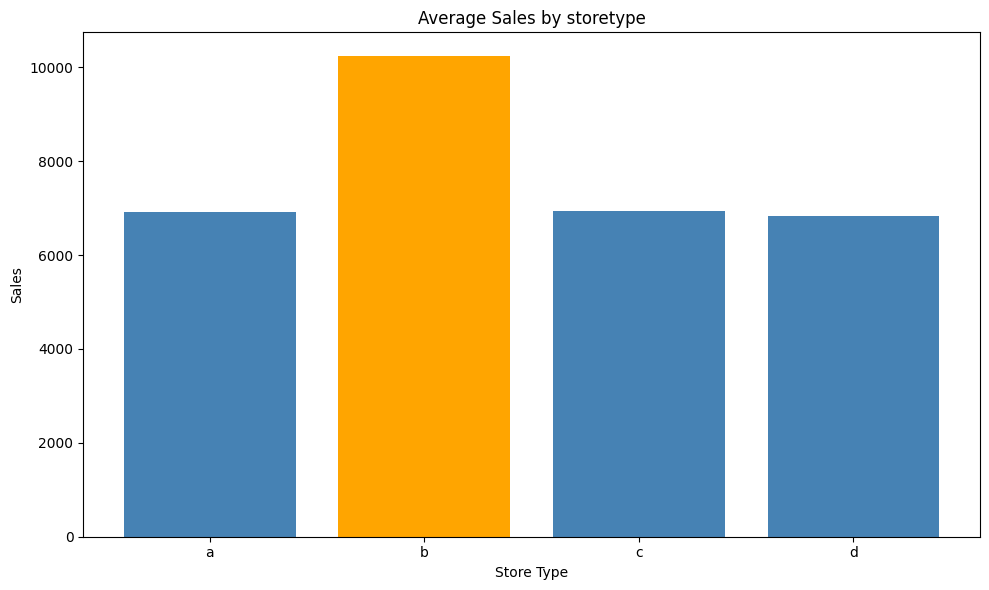

In [17]:
plt.figure(figsize = (10,6))
plt.bar(storetype_sales.index, storetype_sales.values, color = ['steelblue','orange','steelblue','steelblue'])
plt.title('Average Sales by storetype')
plt.xlabel('Store Type')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('../charts/storetype_sales.png', dpi =150)
plt.show()

## Competition Distance vs Sales
Does nearby competition hurt sales?
Not really. Some of the top performing stores actually have competition within 500 meters.

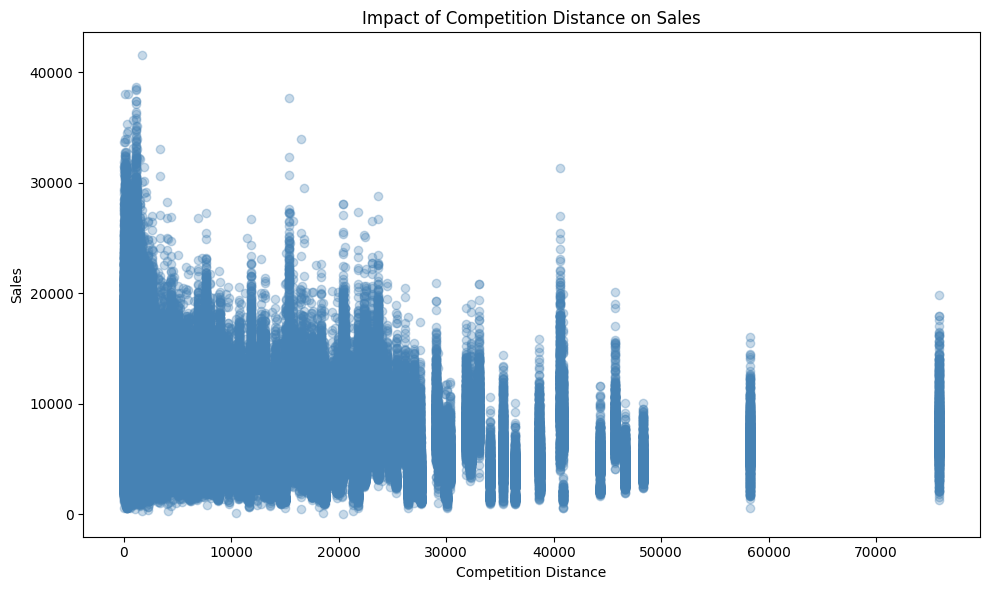

In [18]:
plt.figure(figsize=(10,6))
plt.scatter(df['competitiondistance'], df['sales'], alpha = 0.3, color='steelblue')
plt.title('Impact of Competition Distance on Sales')
plt.xlabel('Competition Distance')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('../charts/Competition_Sales.png', dpi = 150)
plt.show()



**Business Question:** Which days generate the highest sales?

**Original read:** Sunday and Monday looked like peak days based on average sales alone (€8,224.72 and €8,216.25).

**The problem with that read:** Averages by day of week don't account for *how many stores are actually open* on each day. Most Rossmann stores close on Sundays. The few that don't tend to be higher-traffic locations, which inflates the Sunday average without that reflecting genuine Sunday demand chain-wide. Verified below.

```sql
SELECT
    dayofweek,
    COUNT(DISTINCT store) AS stores_open,
    ROUND(AVG(sales)::numeric, 2) AS avg_daily_sales
FROM rossmann_sales
GROUP BY dayofweek
ORDER BY dayofweek;
```

**Confirmed:** Running the open-store count alongside the averages settles it.

| dayofweek | stores_open | avg_daily_sales |
|---|---|---|
| 1 (Mon) | 1,115 | €8,216.25 |
| 2 (Tue) | 1,115 | €7,088.41 |
| 3 (Wed) | 1,115 | €6,728.79 |
| 4 (Thu) | 1,115 | €6,768.21 |
| 5 (Fri) | 1,115 | €7,073.03 |
| 6 (Sat) | 1,115 | €5,875.08 |
| 7 (Sun) | **33** | €8,224.72 |

Only 33 of 1,115 stores open on Sundays. The other six days have the full chain trading. Sunday's average looks nearly identical to Monday's, but it's coming from 3% of the store base, almost certainly a small group of high-traffic flagship locations that chose to stay open. It isn't evidence that Sunday is a strong sales day chain-wide. It's evidence that the handful of stores that open on Sunday are already strong performers, which is a different finding entirely.

**Corrected finding:** Monday is the strongest full-chain trading day at €8,216, with all 1,115 stores open. Sunday should not be reported as a "peak day" without the 33-store caveat attached, since it isn't a comparable measurement to the other six days. Saturday is the lowest full-chain trading day at €5,875.

## Sales by Day of Week
Which days generate the highest sales?  
At first glance, Sunday and Monday looked like the peak days, €8,224.72 and €8,216.25 average sales respectively.  
But that read has a problem: averaging by dayof weeks ignores how many stores are actually open on each day. Most Rossmann stores close on Sundays.  
The few that stay open tend to be higher-traffic locations, which pushes the Sunday average up without that reflecting real Sunday demand across the chain.  
Here's the check:  
```sql
SELECT
    dayofweek,
    COUNT(DISTINCT store) AS stores_open,
    ROUND(AVG(sales)::numeric, 2) AS avg_daily_sales
FROM rossmann_sales
GROUP BY dayofweek
ORDER BY dayofweek;
```
Running the open-store count next to the averages confirms it.  
| dayofweek | stores_open | avg_daily_sales |
|---|---|---|
| 1 (Mon) | 1,115 | €8,216.25 |
| 2 (Tue) | 1,115 | €7,088.41 |
| 3 (Wed) | 1,115 | €6,728.79 |
| 4 (Thu) | 1,115 | €6,768.21 |
| 5 (Fri) | 1,115 | €7,073.03 |
| 6 (Sat) | 1,115 | €5,875.08 |
| 7 (Sun) | **33** | €8,224.72 |  

Only 33 of 1,115 stores open on Sundays. Every other day runs the full chain. So Sunday's average sits right next to Monday's, but it's built on 3% of stores, likely a handful of flagship locations that were already busy enough to justify staying open on Sunday were strong to begin with, which is a completely different claim.  
Monday is the actual strongest full-chain day, €8.126.25 across all 1,115 stores. Sunday's number shouldn't be quoted as a **peak day** without the 33-store caveat attached, since it's not measuring the same thing as the other six days. Saturday comes in weakest, €5,875.08.

In [19]:
weekly_sales = df.groupby('dayofweek')['sales'].mean()
weekly_sales

dayofweek
1    8216.252259
2    7088.409086
3    6728.786679
4    6768.214973
5    7073.034133
6    5875.084935
7    8224.723908
Name: sales, dtype: float64

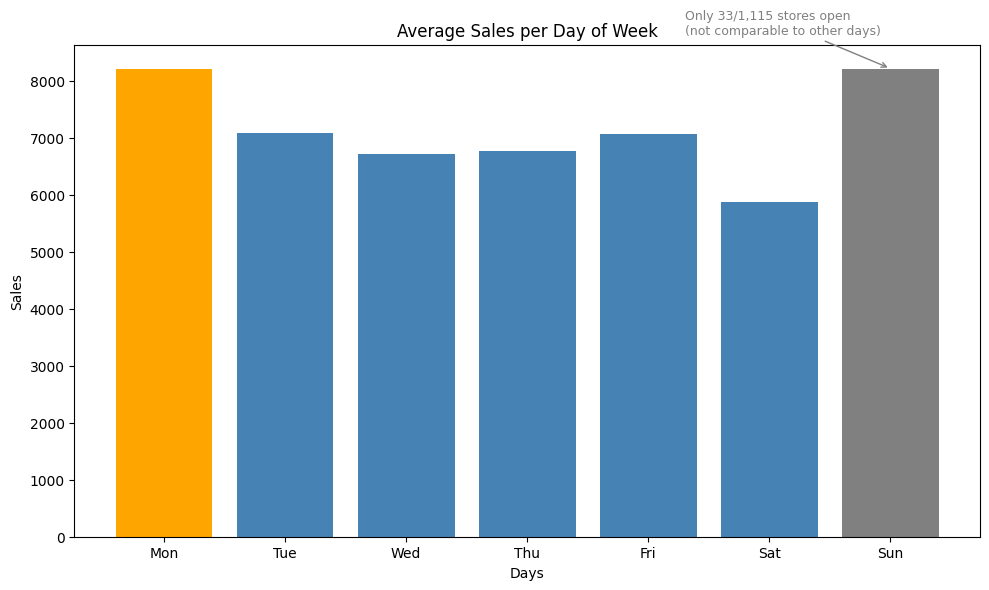

In [20]:
plt.figure(figsize=(10,6))

days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
colors = ['orange','steelblue','steelblue','steelblue','steelblue','steelblue','gray']

bars = plt.bar(days, weekly_sales.values, color=colors)

plt.title('Average Sales per Day of Week')
plt.xlabel('Days')
plt.ylabel('Sales')

# Annotate Sunday to flag the store-count issue directly on the chart
plt.annotate('Only 33/1,115 stores open\n(not comparable to other days)',
             xy=(6, weekly_sales.values[6]),
             xytext=(4.3, weekly_sales.values[6] + 600),
             fontsize=9, color='gray',
             arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.savefig('../charts/weeklysales.png', dpi=150)
plt.show()

In [21]:
# Do promotions work better on certain days?
promo_day = df.groupby(['dayofweek', 'promo'])['sales'].mean().unstack()
print(promo_day)

promo                0            1
dayofweek                          
1          6222.727829  9772.910890
2          5716.412127  8277.630871
3          5617.729043  7685.682535
4          5750.882664  7598.788372
5          6344.411832  7744.388208
6          5875.084935          NaN
7          8224.723908          NaN
